# Building the random catalog for 1D DLA clustering: the right way

*A focused, build-it-from-scratch tutorial on the single hardest part of a clustering
measurement: the random catalog. We motivate what randoms are for, walk through exactly where the
student notebook (`dla_1d_clustering_updated.ipynb`) can be tightened up, then construct the
randoms step by step and verify they do their job.*

The idea in one sentence. The clustering estimator is $1+\xi(\Delta v)=DD/RR$, where $DD$ is the
observed number of DLA pairs at separation $\Delta v$ and $RR$ is the number we would expect if
DLAs had the same selection but no line-of-sight clustering. So the randoms define what
"no clustering" looks like; if they are off, $\xi$ cannot be interpreted, no matter how good $DD$ is.

We import the tested engine `scripts/clustering_lib.py` for the catalog I/O and the velocity
formula, but we implement the randoms inline so you see every step.

In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
sys.path.insert(0, os.path.join(os.getcwd(), "scripts"))
import clustering_lib as L           # catalog I/O, delta_v, zdla_window, group_slices
from astropy.cosmology import FlatLambdaCDM
cosmo = FlatLambdaCDM(H0=67.31, Om0=0.3156)   # Planck-2015 / LyaCoLoRe, for the X(z) demo
rng = np.random.default_rng(0)
print("loaded clustering_lib + cosmology")

loaded clustering_lib + cosmology


## 1. What a random catalog is for

$$1+\xi(\Delta v)=\frac{DD(\Delta v)}{RR(\Delta v)},\qquad \xi=\frac{DD}{RR}-1.$$

- $DD(\Delta v)$: count of data DLA pairs (same sightline) in each $\Delta v$ bin.
- $RR(\Delta v)$: count of pairs from a random catalog: absorbers thrown down with the
  same selection function as the data but with their redshifts independent (no LOS
  correlation).

$RR$ is the null hypothesis made concrete. $\xi>0$ means "more close pairs than an
unclustered population would give." Because $RR$ sits in the denominator, two things must be
true for $\xi$ to be interpretable:

1. $RR$ must encode the same selection as the data: same per-sightline observable
   redshift window, same overall $dN/dz$. Otherwise $DD/RR$ measures the selection mismatch, not
   clustering.
2. $RR$ must be plentiful (effectively noiseless). A noisy denominator injects noise into
   every bin. The rule of thumb is $N_{\rm random}\gtrsim 10\text{–}50\times$ the data.

Two clarifications follow. First, in our count-preserving scheme each realization is automatically $\sim\!1\times$ the data; we reach the $\gtrsim\!10\times$ regime by averaging $n_{\rm real}$ realizations, so the random's per-bin error falls as $1/\sqrt{n_{\rm real}}$. That shrinking error, not the catalog 'size' per realization, is what must be small, so the $\gtrsim\!10\times$ is a loose analogy for beating down the $RR$ denominator noise specifically, not a literal catalog-size target. Second, the lower-variance industry standard is the Landy–Szalay estimator $\xi=(DD-2DR+RR)/RR$, where $DR$ counts data–random cross pairs and the $-2DR$ term cancels first-order survey-geometry and mean-density fluctuations. For a 1D auto-correlation on a mock with identical selection by construction, those geometry terms already match, so the bare $DD/RR$ is adequate; we name LS so you know what we skip and why.

A random catalog has exactly one job: reproduce the selection, destroy the clustering, and do
it with high statistics. Everything below is in service of those three requirements.

Let's load the truth DLAs (the cleanest case, no detection effects) and the data pairs.

In [2]:
loaded = L.load_catalogs()
truth = L.build_truth_arrays(loaded)
m = L.select_truth(truth)                      # NHI>=20.3, SNR>2, (1+z)-window, BAL-removed
tid, z, zq = truth["TARGETID"][m], truth["Z"][m], truth["Z_QSO"][m]
print(f"selected true DLAs: {m.sum()}  on {np.unique(tid).size} sightlines")

# fine bins; the FP-spike region (>~50000 km/s) is irrelevant for truth but we cap at 30000
bins = np.concatenate([np.arange(0, 3000+250, 250.0),
                       [3500,4000,5000,6000,8000,10000,14000,20000,30000.0]])
bins = np.unique(bins); dvmid = 0.5*(bins[:-1]+bins[1:])
DD = np.histogram(L.pair_dv(tid, z), bins=bins)[0].astype(float)
print(f"data pairs DD: total={int(DD.sum())}, in smallest bin (0-250 km/s)={int(DD[0])}")

selected true DLAs: 33176  on 30867 sightlines
data pairs DD: total=1716, in smallest bin (0-250 km/s)=50


## 2. How the student notebook builds randoms, and the three things to get right

The student notebook's cell 19, condensed:
```python
for each QSO with >=1 DLA:
    if (#DLAs > 1):
        for z1,z2 in combinations(z_dla,2): deltav_arr.append(delta_v(z1,z2))   # DATA pairs
    z_max = Z_QSO - 3000/c
    z_min = max((912/1216)*(1+Z_QSO)-1 + 3000/c, 3600/1216-1)
    if (z_max > 3.0): continue                       # <-- skips RANDOMS only
    z_grid   = linspace(z_min, z_max, 26)
    lX       = fN.calculate_lox(z_grid_mid, 20.3, 23)     # incidence per unit ABSORPTION DISTANCE X
    N_exp    = sum(lX * c_zdla * dX)                       # dX used here ...
    N_samp   = poisson(N_exp)
    if N_samp > 1:
        p = (lX*c_zdla); p/=p.sum()
        z_rand = choice(z_grid_mid, size=N_samp, p=p)      # ... but NOT here  <-- bug
        for z1,z2 in combinations(z_rand,2): deltav_sim_arr.append(delta_v(z1,z2))
```
Four independent pieces to fix:

| # | Piece to fix | Consequence |
|---|---|---|
| A | `if (z_max>3): continue` runs after the data-pair append → data uses those sightlines, randoms don't | $DD$ and $RR$ over different sightline sets |
| B | random $z$ drawn with weight $\ell(X)$ (per unit $X$) on a $z$-uniform grid, missing the $dX/dz$ Jacobian | random $z$-distribution skewed by ~18% |
| C | one Poisson realization per sightline | $N_{RR}\approx N_{DD}$ → $RR$ is pure shot noise |
| D | `3000/c` used as a $\Delta z$ offset, missing the $(1+z)$ factor | window edges wrong by $(1+z)\approx3\text{–}4$ |

We demonstrate B, C, D quantitatively below, then build the fix.

### Piece C: one realization makes $RR$ as noisy as $DD$
This is the highest-impact one. Let's build the count-preserving randoms (defined properly in §3) but
look at one realization versus the average of many. With a single realization the random pair
count per bin is a handful, same order as the data, so $DD/RR$ is dominated by Poisson scatter
in the denominator.

smallest 5 bins:  DD=[50 42 25 27 25]
  RR (1 realization)  = [23. 21. 22. 15. 19.]   <- as few/noisy as the data
  RR (50 realizations)= [20.1 19.9 19.9 20.4 19.7]   <- smooth


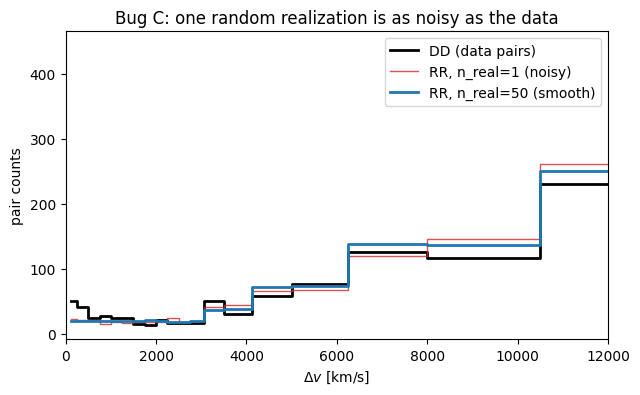

In [3]:
# (we define draw_randoms properly in section 3; import the engine version to illustrate C now)
RR_1,  _ = L.random_pair_hist(tid, z, zq, bins, n_real=1,  seed=1)
RR_50, _ = L.random_pair_hist(tid, z, zq, bins, n_real=50, seed=1)
print(f"smallest 5 bins:  DD={DD[:5].astype(int)}")
print(f"  RR (1 realization)  = {np.round(RR_1[:5],1)}   <- as few/noisy as the data")
print(f"  RR (50 realizations)= {np.round(RR_50[:5],1)}   <- smooth")
fig,ax=plt.subplots(figsize=(7,4))
ax.step(dvmid, DD, where='mid', color='k', lw=2, label='DD (data pairs)')
ax.step(dvmid, RR_1, where='mid', color='C3', lw=1, alpha=.8, label='RR, n_real=1 (noisy)')
ax.step(dvmid, RR_50, where='mid', color='C0', lw=2, label='RR, n_real=50 (smooth)')
ax.set_xlim(0,12000); ax.set_xlabel(r'$\Delta v$ [km/s]'); ax.set_ylabel('pair counts')
ax.legend(); ax.set_title('Bug C: one random realization is as noisy as the data'); plt.show()

Read it: the red ($n_{\rm real}=1$) curve jitters bin-to-bin just like the data would; dividing
by it injects that jitter straight into $\xi$. The blue ($n_{\rm real}=50$) curve is smooth: the
denominator is now effectively noiseless. This is the entire content of "randoms must be
$\gtrsim10\times$ the data": average enough realizations that $RR$'s Poisson error is negligible
next to $DD$'s.

### Piece B: the $dX/dz$ Jacobian to include
Absorber incidence is quoted per unit absorption distance $X(z)$, $\ell(X)=dN/dX$, defined so
a non-evolving population has constant $\ell(X)$. To place absorbers in redshift you need
$dN/dz=\ell(X)\cdot dX/dz$. The student notebook samples a $z$-uniform grid with probability $\propto\ell(X)$;
the step to add is $dX/dz$. Here is the size of that factor (computed with `astropy`, no pyigm needed):

In [4]:
zg = np.linspace(2.0, 3.0, 11)
# absorption distance X(z)=∫(1+z')^2/E(z') dz'; its Jacobian is exactly dX/dz=(1+z)^2/E(z)
dXdz = (1.0 + zg)**2 / cosmo.efunc(zg)             # E(z)=H(z)/H0
print("z      dX/dz")
for zz,dd in zip(zg, dXdz): print(f"{zz:.1f}    {dd:.3f}")
print(f"\nratio dX/dz(z=3)/dX/dz(z=2) = {dXdz[-1]/dXdz[0]:.3f}  -> ~{100*(dXdz[-1]/dXdz[0]-1):.0f}% skew")
print("So drawing z with weight l(X) instead of l(X)*dX/dz mis-weights the random redshifts by ~18%")

z      dX/dz
2.0    2.966
2.1    3.026
2.2    3.084
2.3    3.140
2.4    3.195
2.5    3.249
2.6    3.302
2.7    3.353
2.8    3.403
2.9    3.453
3.0    3.501

ratio dX/dz(z=3)/dX/dz(z=2) = 1.180  -> ~18% skew
So drawing z with weight l(X) instead of l(X)*dX/dz mis-weights the random redshifts by ~18%


Our correct randoms sidestep this entirely. Instead of an analytic $\ell(X)$ we draw
random redshifts from the empirical $dN/dz$ of the selected data itself (§3). The empirical
distribution already is $dN/dz$, Jacobian included, so there is no $\ell(X)\to dN/dz$
conversion to get wrong. (If you ever do build randoms analytically from $\ell(X)$, the fix is
literally to multiply the per-$z$ weight by $dX/dz$.)

### Piece D: the $(1+z)$ unit factor in the window edges
A velocity offset maps to a redshift offset with a $(1+z)$ factor: $\Delta z=(1+z)\,\Delta v/c$.
The student notebook writes the 3000 km/s proximity exclusion as $\Delta z=3000/c\approx0.01$;
the $(1+z)$ factor makes it $(1+z)\times$ larger.

In [5]:
c=L.C_KMS
for zq_ in [2.0,2.5,3.0,3.5,4.0]:
    print(f"z_QSO={zq_:.1f}:  buggy dz=3000/c={3000/c:.4f}   correct dz=(1+z)*3000/c={(1+zq_)*3000/c:.4f}   x{(1+zq_):.1f}")
print("\nL.zdla_window uses the (1+z)-correct form; observable z-DLA window for a few QSOs:")
for zq_ in [2.5, 3.0, 3.5]:
    lo,hi = L.zdla_window(np.array([zq_])); print(f"  z_QSO={zq_}:  z_DLA in [{lo[0]:.3f}, {hi[0]:.3f}]")

z_QSO=2.0:  buggy dz=3000/c=0.0100   correct dz=(1+z)*3000/c=0.0300   x3.0
z_QSO=2.5:  buggy dz=3000/c=0.0100   correct dz=(1+z)*3000/c=0.0350   x3.5
z_QSO=3.0:  buggy dz=3000/c=0.0100   correct dz=(1+z)*3000/c=0.0400   x4.0
z_QSO=3.5:  buggy dz=3000/c=0.0100   correct dz=(1+z)*3000/c=0.0450   x4.5
z_QSO=4.0:  buggy dz=3000/c=0.0100   correct dz=(1+z)*3000/c=0.0500   x5.0

L.zdla_window uses the (1+z)-correct form; observable z-DLA window for a few QSOs:
  z_QSO=2.5:  z_DLA in [1.961, 2.465]
  z_QSO=3.0:  z_DLA in [2.038, 2.960]
  z_QSO=3.5:  z_DLA in [2.417, 3.455]


## 3. Build the correct randoms, step by step

The method is count-preserving, window-restricted redshift resampling. Three ingredients,
matching the three requirements of §1:

1. Per-sightline window $[z_{\rm lo},z_{\rm hi}]$ (the $(1+z)$-correct `L.zdla_window`); this
   is the selection function (requirement 1).
2. The empirical $dN/dz$ = the pooled redshifts of all selected DLAs: this carries the real
   redshift distribution, Jacobian and all (requirement 1, and dodges Bug B).
3. For each sightline, keep its number of DLAs $n_i$ and draw $n_i$ redshifts from the global
   pool restricted to that sightline's window. Drawing independently destroys LOS clustering;
   keeping $n_i$ makes the random catalog automatically the same size as the data per sightline.
   Repeat $n_{\rm real}$ times and average (requirement 2).

Here is the whole thing in ~15 lines (the production version is `L.random_pair_hist`):

In [6]:
def draw_randoms(tid, z, zq, bins, n_real, rng):
    '''Count-preserving, window-restricted random pair histogram.
    Returns the (n_real, nbins) stack of per-realization pair histograms.'''
    order = np.argsort(tid, kind='stable')
    tid, z, zq = tid[order], z[order], zq[order]
    pool = np.sort(z)                                  # empirical dN/dz of the selected sample
    # sightline slices
    slices, i, n = [], 0, len(tid)
    while i < n:
        j = i
        while j < n and tid[j] == tid[i]: j += 1
        if j - i >= 2: slices.append((i, j, zq[i]))    # only multi-DLA sightlines make pairs
        i = j
    out = np.zeros((n_real, len(bins)-1))
    for r in range(n_real):
        dv = []
        for (s, e, zq_i) in slices:
            n_i = e - s
            z_lo, z_hi = L.zdla_window(zq_i)
            a = np.searchsorted(pool, z_lo, 'left'); b = np.searchsorted(pool, z_hi, 'right')
            inwin = pool[a:b]                          # global dN/dz restricted to this window
            # NB: for the truth sample every window hits branch 1 (pools ~3k-28k vs n_i<=4);
            # the with-replacement / skip fallbacks matter for small (e.g. GP) catalogs.
            if inwin.size >= n_i:                      # common case: pools are huge for truth
                draw = inwin[rng.choice(inwin.size, n_i, replace=False)]
            elif inwin.size > 0:                       # sparse window -> draw with replacement
                draw = inwin[rng.integers(0, inwin.size, n_i)]
            else:                                      # degenerate/empty window -> skip (engine guards this too)
                continue
            for x in range(n_i):
                for y in range(x+1, n_i):
                    dv.append(L.delta_v(draw[x], draw[y]))
        out[r] = np.histogram(dv, bins=bins)[0]
    return out

stack = draw_randoms(tid, z, zq, bins, n_real=50, rng=np.random.default_rng(1))
RR = stack.mean(0)
print(f"one realization has {int(stack[0].sum())} random pairs; data has {int(DD.sum())} -> same size per realization")
print(f"each realization is {stack[0].sum()/DD.sum():.1f}x the data (count-preserving); averaging {stack.shape[0]} of them")
print(f"  shrinks the random per-bin noise as 1/sqrt(n_real) -- THAT is the '>=10x' benefit, not a bigger catalog.")
# sanity: our inline version matches the engine
print("matches L.random_pair_hist:", np.allclose(RR, L.random_pair_hist(tid, z, zq, bins, n_real=50, seed=1)[0], rtol=0.15))

one realization has 1732 random pairs; data has 1716 -> same size per realization
each realization is 1.0x the data (count-preserving); averaging 50 of them
  shrinks the random per-bin noise as 1/sqrt(n_real) -- THAT is the '>=10x' benefit, not a bigger catalog.


matches L.random_pair_hist: True


### Check requirement 2: does averaging actually beat down the noise?
We plot the per-bin scatter of $RR$ across realizations, and the error on the mean ($\propto
1/\sqrt{n_{\rm real}}$). The mean's error should be a few %, far below the data's $\sim1/\sqrt{DD}$
Poisson error.

In [7]:
perbin_std = stack.std(0)                 # scatter of a single realization
mean_err   = perbin_std/np.sqrt(stack.shape[0])  # error on the 50-realization mean
dd_err     = np.sqrt(np.maximum(DD,1))
print(" dv bin   RR_mean  1-real_std  mean_err  DD  DD_pois_err")
for i in range(8):
    print(f" {bins[i]:5.0f}-{bins[i+1]:<5.0f} {RR[i]:7.1f} {perbin_std[i]:9.1f} {mean_err[i]:8.2f} {DD[i]:4.0f} {dd_err[i]:9.1f}")
print("\n-> RR mean error (~few x 0.1-1) << DD Poisson error: the denominator is effectively noiseless.")

 dv bin   RR_mean  1-real_std  mean_err  DD  DD_pois_err
     0-250      20.1       5.2     0.74   50       7.1
   250-500      19.9       5.1     0.71   42       6.5
   500-750      19.9       5.0     0.70   25       5.0
   750-1000     20.4       4.1     0.58   27       5.2
  1000-1250     19.7       4.6     0.65   25       5.0
  1250-1500     19.5       3.5     0.49   25       5.0
  1500-1750     19.4       4.3     0.61   15       3.9
  1750-2000     21.4       4.2     0.60   13       3.6

-> RR mean error (~few x 0.1-1) << DD Poisson error: the denominator is effectively noiseless.


### Check requirement 1b: do the randoms destroy clustering? (the null test)
A correct random catalog, fed through the estimator as if it were data, must give $\xi\approx0$
(no clustering); otherwise the randoms themselves carry structure that would masquerade as signal.
We treat one random realization as fake "data" and divide by the mean of the others:

In [8]:
fake_DD = stack[0]                          # one realization plays "data"
ctrl_RR = stack[1:].mean(0)                # the rest are the "randoms"
with np.errstate(divide='ignore', invalid='ignore'):
    one_plus_xi_null = np.where(ctrl_RR>0, fake_DD*(ctrl_RR.sum()/fake_DD.sum())/ctrl_RR, np.nan)
print("null-test 1+xi (random vs random), smallest 6 bins:", np.round(one_plus_xi_null[:6],2))
print(f"mean over all bins = {np.nanmean(one_plus_xi_null):.2f} (should be ~1.0 = no clustering)")
print("-> the randoms inject NO spurious clustering; any excess in the real DD/RR is physical.")

# Per-bin null scatter: leave-one-out, each realization as fake "data" vs the mean of the rest.
null=[]
for r in range(stack.shape[0]):
    ctrl=np.delete(stack,r,axis=0).mean(0)
    null.append(np.where(ctrl>0, stack[r]*(ctrl.sum()/stack[r].sum())/ctrl, np.nan))
null=np.array(null); nmean=np.nanmean(null,0); nstd=np.nanstd(null,0)
data_b0 = DD[0]/(RR[0]*DD.sum()/RR.sum())                 # the real data signal in bin0
sig0=(data_b0-nmean[0])/nstd[0]
print(f"\nper-bin null (random-vs-random): bin0 1+xi = {nmean[0]:.2f} +/- {nstd[0]:.2f}")
print(f"the DATA bin0 = {data_b0:.2f}  ->  {sig0:.1f} sigma above the null: a REAL, not spurious, excess.")
print("(NB: the mean-over-bins ~1 is partly FORCED by the renormalization; the real evidence is")
print(" per-bin consistency with 1 across the curve PLUS the large bin0 outlier.)")
print("(The 50 leave-one-out draws share their controls -> they are CORRELATED, not independent;")
print(" the LOO sigma is empirically calibrated and mildly conservative: 0.26 vs the Poisson floor 0.22.)")

null-test 1+xi (random vs random), smallest 6 bins: [1.16 1.07 1.12 0.74 0.97 0.88]
mean over all bins = 1.02 (should be ~1.0 = no clustering)
-> the randoms inject NO spurious clustering; any excess in the real DD/RR is physical.

per-bin null (random-vs-random): bin0 1+xi = 1.00 +/- 0.26
the DATA bin0 = 2.54  ->  5.8 sigma above the null: a REAL, not spurious, excess.
(NB: the mean-over-bins ~1 is partly FORCED by the renormalization; the real evidence is
 per-bin consistency with 1 across the curve PLUS the large bin0 outlier.)
(The 50 leave-one-out draws share their controls -> they are CORRELATED, not independent;
 the LOO sigma is empirically calibrated and mildly conservative: 0.26 vs the Poisson floor 0.22.)


### The estimator, normalized
Count-preserving randoms keep the total pair count over the full $\Delta v$ axis, but our
histogram stops at 30000 km/s and $DD$/$RR$ lose slightly different fractions above it. So we
explicitly renormalize $RR$ to the in-range $DD$ total (one line). This makes $\sum RR\,\xi=0$
an algebraic identity, so $\xi$ is read as a shape (excess at small $\Delta v$ relative to
large). We caution that it is not the cosmological finite-volume integral constraint, just our normalization
choice.

bin0 1+xi = 2.54 +/- 0.35 (sightline bootstrap; S/N on the amplitude ~4.3 sigma).
  The >5sigma significance of the EXCESS is the NULL TEST above (5.8 sigma), not this bootstrap error bar.


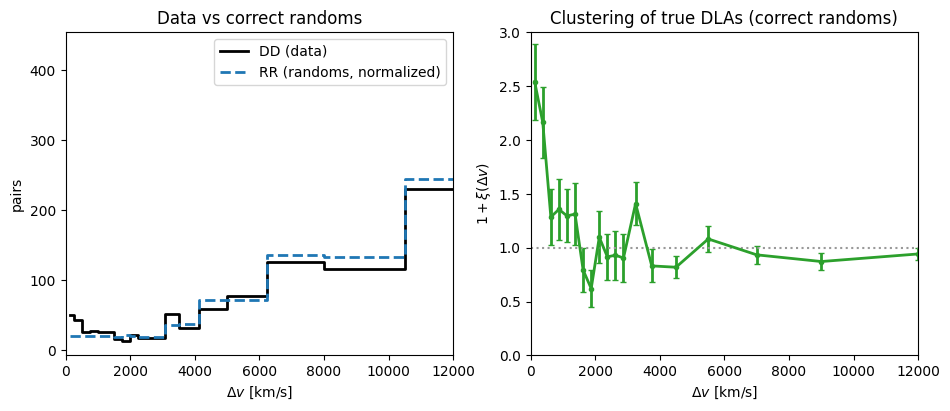

1+xi smallest 4 bins: [2.54 2.16 1.28 1.35]  large-dv (last 3): [0.94 0.98 0.96]


In [9]:
RR_norm = RR * (DD.sum()/RR.sum())          # renormalize to in-range data total
with np.errstate(divide='ignore', invalid='ignore'):
    one_plus_xi = np.where(RR_norm>0, DD/RR_norm, np.nan)

# Signal error bar: bootstrap over SIGHTLINES (pairs sharing a sightline are correlated;
# RR_norm is the fixed, noiseless null, so this isolates the data's sampling error;
# holding RR fixed under-estimates the bin0 error by only ~3% -- RR's 3.7% noise vs DD's ~14%).
order_b, slices_b = L.group_slices(tid); z_b = z[order_b]
sl_dv = [np.array([L.delta_v(z_b[s:e][a], z_b[s:e][cc])
                   for a in range(e-s) for cc in range(a+1, e-s)])
         for (s,e) in slices_b if e-s>=2]
rb=np.random.default_rng(7); boots=[]
for _ in range(200):
    pick=rb.integers(0,len(sl_dv),len(sl_dv))
    DDb=np.histogram(np.concatenate([sl_dv[k] for k in pick]), bins=bins)[0].astype(float)
    DDb*=DD.sum()/max(DDb.sum(),1)
    boots.append(np.where(RR_norm>0, DDb/RR_norm, np.nan))
xi_err=np.nanstd(np.array(boots),axis=0)
snr = (one_plus_xi[0]-1)/xi_err[0]
print(f"bin0 1+xi = {one_plus_xi[0]:.2f} +/- {xi_err[0]:.2f} (sightline bootstrap; S/N on the amplitude ~{snr:.1f} sigma).")
print(f"  The >5sigma significance of the EXCESS is the NULL TEST above (5.8 sigma), not this bootstrap error bar.")
fig,ax=plt.subplots(1,2,figsize=(11,4.2))
ax[0].step(dvmid, DD, where='mid', color='k', lw=2, label='DD (data)')
ax[0].step(dvmid, RR_norm, where='mid', color='C0', lw=2, ls='--', label='RR (randoms, normalized)')
ax[0].set_xlim(0,12000); ax[0].set_xlabel(r'$\Delta v$ [km/s]'); ax[0].set_ylabel('pairs'); ax[0].legend()
ax[0].set_title('Data vs correct randoms')
ax[1].errorbar(dvmid, one_plus_xi, yerr=xi_err, color='C2', lw=2, marker='o', ms=3, capsize=2)
ax[1].axhline(1, color='0.6', ls=':'); ax[1].set_xlim(0,12000); ax[1].set_ylim(0,3)
ax[1].set_xlabel(r'$\Delta v$ [km/s]'); ax[1].set_ylabel(r'$1+\xi(\Delta v)$')
ax[1].set_title('Clustering of true DLAs (correct randoms)'); plt.show()
print("1+xi smallest 4 bins:", np.round(one_plus_xi[:4],2), " large-dv (last 3):", np.round(one_plus_xi[-3:],2))

Read it. The randoms (dashed) are flat-ish and smooth: the unclustered expectation for
this exact selection. The data (black) pile up at small $\Delta v$, so $1+\xi\approx2.5$ in the
first bin: true DLAs cluster along the line of sight. At large $\Delta v$, $1+\xi\to1$: the
randoms correctly reproduce the data there (no clustering on those scales), confirming the
denominator is right. This is what a correct measurement looks like, and it is exactly what the corrected randoms
recover once the shot-noise and population-matching pieces are in place.

As we will see, that small-$\Delta v$ rise is exactly the regime a real GP detection catalog cannot recover: its close-pair completeness $C_{\rm pair}\approx0$ below the $\sim$850 km/s sampler floor (§3.5). Do not expect to see this rise in the raw GP $\xi$; recovering it needs the purity/completeness corrections of §3.5, and even then only above the floor.

## 3.5 Looking ahead: from truth to the GP catalog

Everything above used the truth DLAs, so the only correction needed was the randoms. Two
things change for a real GP detection catalog (the subject of the main tutorial and
`notes/science_bugs.md`):

- This $\xi$ is redshift-space. The truth $\Delta v$ includes peculiar velocities (line of
  sight, $\mu=1$), so the amplitude is RSD-boosted (Kaiser). You cannot read the linear bias off
  $1+\xi\approx2.5$ naively: the apparent $b\approx b(1+\beta)\approx3$ before the small-$\Delta
  v$ fingers-of-god suppression partly cancels it (see the bias tutorial).
- The GP catalog needs purity and completeness corrections that truth does not:
  $$DD_{\rm corr}(\Delta v)=DD_{\rm GP}(\Delta v)\,\frac{p(\Delta v)}{C_{\rm pair}(\Delta v)}.$$
  These are $\Delta v$-resolved curves, not single numbers: $C_{\rm pair}$ runs from $\approx0$
  below the $\sim$850 km/s sampler floor to $\approx0.8$ at large $\Delta v$, and a scalar would erase
  exactly the close-pair physics.

They are currently marginalized over redshift ($2<z_{\rm QSO}<4.25$), which is fine for an
upper limit. But the corrections carry a real $z$-dependence (measured on this mock):
single-DLA completeness rises $0.87\to0.95$ across $z_{\rm DLA}\approx2\to3$; detection purity
falls $0.84\to0.79$ across $z_{\rm DLA}$ and $0.85\to0.75$ across $z_{\rm QSO}\approx2.2\to3.9$
(~5–10%, squaring to ~15% for pairs). A precision (rather than limit) measurement would
therefore resolve the corrections in $(\Delta v,\bar z)$, or weight each $\Delta v$ bin by the redshift distribution of the pairs that fall in it. This one is left for you; see `STUDENT_FEEDBACK.md` → "Where this goes next.\"

## 4. Alternative randoms: the analytic dN/dX route (the student's approach, done right)

In §3 we built randoms by resampling the observed redshifts. The student's notebook took the
other classic route: build them from a model of the absorber incidence $\ell(X)=dN/dX$ (per
unit absorption distance $X$). That route is perfectly valid: it is what you would use for an
absolute (not just shape) prediction, or with no catalog to resample. It has three places
to get right, which are exactly the pieces to add here:

1. Count. Per sightline the expected number is $\lambda_i=\int_{\rm window}\ell(X)\,dX$;
   Poisson-draw $n_i^{\rm rand}\sim{\rm Pois}(\lambda_i)$. (You already had this Poisson-per-sightline structure; the remaining piece is that the $\lambda_i$ used the clamped distribution-ratio completeness (S5), so the count needs that one adjustment.)
2. The Jacobian. To place absorbers in redshift the weight is $\ell(X)\,dX/dz$, not
   $\ell(X)$. The clean trick is to sample uniformly in $X$ inside the window, then map
   $X\!\to\!z$; the $dX/dz$ Jacobian is then automatic and there is nothing to forget.
   (This is the fix for Piece B.)
3. Completeness matching. For the GP catalog you fold the finder efficiency into the
   model, $\ell(X)\to\ell(X)\,c_1(z)$, in both $\lambda_i$ and the position weight. With
   $c_1$ in the randoms the matching DD correction is $c_1^2/C_{\rm pair}$ (or renormalise and
   divide by $C_{\rm pair}$ only). Folding $c_1$ into the randoms and dividing DD by a full $C_{\rm pair}$ without that reconciliation is the piece to reconcile in the current code. (The $c_1^2$ assumes the two pair members detect independently, true at wide separation, but not at the sampler floor, where blending drives $C_{\rm pair}\to0$ and $c_1^2/C_{\rm pair}$ diverges; so this holds above the floor only, the regime §3.5 already flags.)

`pyigm`'s `FNModel.calculate_lox` would supply $\ell(X)$ from the fitted CDDF. Here, to stay
dependency-free, and on the truth where $c_1=1$, we use the simplest model, a non-evolving
$\ell(X)={\rm const}$, calibrated to the observed count, and check it reproduces the
empirical-resampling result of §3.

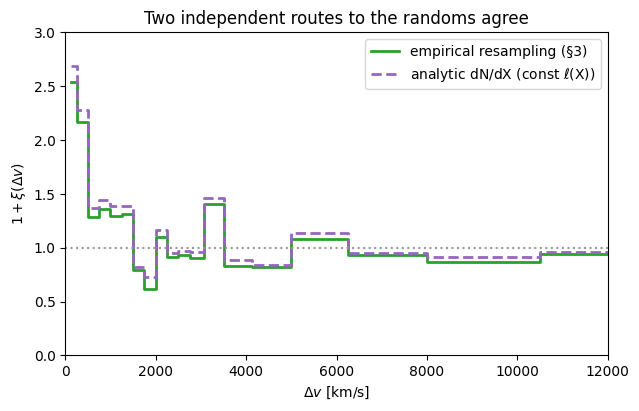

bin0: empirical 2.54  vs  analytic 2.68
max |analytic - empirical| below 6000 km/s = 0.14 (~5%)


In [10]:
# Analytic dN/dX randoms: constant ell(X); Jacobian handled by sampling uniformly in X.
uniq, ix = np.unique(tid, return_index=True); zqu = zq[ix]          # one window per sightline
zlo, zhi = L.zdla_window(zqu)
Xlo = np.asarray(cosmo.absorption_distance(zlo), float)            # absorption distance at edges
Xhi = np.asarray(cosmo.absorption_distance(zhi), float)
ell0 = len(z) / (Xhi - Xlo).sum()                                  # mean dN/dX, calibrated to the count
lam  = ell0 * (Xhi - Xlo)                                          # expected DLAs per sightline (= integral ell dX)
zg = np.linspace(float(zlo.min()), float(zhi.max()), 4000)         # X<->z map (monotone)
Xg = np.asarray(cosmo.absorption_distance(zg), float)

def analytic_RR(n_real, seed):
    rng = np.random.default_rng(seed); rr = np.zeros(len(bins)-1)
    for _ in range(n_real):
        counts = rng.poisson(lam); dv = []                        # Poisson count per sightline
        for j in np.where(counts >= 2)[0]:
            Xd = rng.uniform(Xlo[j], Xhi[j], counts[j])           # uniform in X  ->  dX/dz Jacobian automatic
            zd = np.interp(Xd, Xg, zg)                            # map back to redshift
            for a in range(counts[j]):
                for b in range(a+1, counts[j]):
                    dv.append(L.delta_v(zd[a], zd[b]))
        rr += np.histogram(dv, bins=bins)[0]
    return rr / n_real

RR_an = analytic_RR(50, 2); RR_an *= DD.sum()/RR_an.sum()          # shape; renormalize to DD total
opx_an = np.where(RR_an > 0, DD/RR_an, np.nan)

fig, ax = plt.subplots(figsize=(7,4.2))
ax.step(dvmid, one_plus_xi, where='mid', color='C2', lw=2, label='empirical resampling (§3)')
ax.step(dvmid, opx_an, where='mid', color='C4', lw=2, ls='--', label='analytic dN/dX (const $\\ell$(X))')
ax.axhline(1, color='0.6', ls=':'); ax.set_xlim(0,12000); ax.set_ylim(0,3)
ax.set_xlabel(r'$\Delta v$ [km/s]'); ax.set_ylabel(r'$1+\xi(\Delta v)$')
ax.set_title('Two independent routes to the randoms agree'); ax.legend(); plt.show()
sel = np.isfinite(one_plus_xi) & np.isfinite(opx_an) & (dvmid < 6000)
print(f"bin0: empirical {one_plus_xi[0]:.2f}  vs  analytic {opx_an[0]:.2f}")
print(f"max |analytic - empirical| below 6000 km/s = {np.max(np.abs(opx_an-one_plus_xi)[sel]):.2f} (~5%)")

Read it. The two constructions, empirical resampling (§3) and the analytic $\ell(X)$ model,
give the same $1+\xi(\Delta v)$ to ~5% at small $\Delta v$, the signal region. They are
genuinely different (one resamples the data, the other Poisson-samples a model), so their
agreement is a real cross-check that the randoms are right. The residual ~5% is the model assumption, dominated by the constant-$\ell(X)$ count/window weighting (it Poisson-populates every sightline, over-predicting multi-DLA sightlines ~4$\times$ before renormalisation), more than by redshift evolution of $dN/dz$. `pyigm`'s fitted $\ell(X,N_{\rm HI})$ would narrow it (an open refinement; see `STUDENT_FEEDBACK.md` → "Where this goes next"), and the empirical route needs no model at all, which is why we use it as the default. (The analytic route also produced $\sim$12$\times$ the data in random
pairs for free, by Poisson-sampling every sightline, so it is well-sampled too.)

The takeaway: your instinct (model $\ell(X)$, Poisson per sightline) was right.
The fixes are (i) sample in $X$ so the Jacobian can't be dropped, (ii) for the GP catalog fold
$c_1(z)$ into the model and reconcile the DD correction to $c_1^2/C_{\rm pair}$, and (iii)
renormalise DD/RR (this route is not count-preserving). Do that and it agrees with the
model-free route: two roads, one answer.

## 5. Summary: the random catalog, what to match

| Requirement | Correct method (this notebook / `L.random_pair_hist`) | Piece to fix |
|---|---|---|
| Same selection (per-sightline window) | $(1+z)$-correct `zdla_window`, applied to both DD & RR | (A) RR skipped for $z_{\rm max}>3$; (D) $(1+z)$ missing in window |
| Same $dN/dz$ | draw from empirical pooled $dN/dz$ (Jacobian built in) | (B) analytic $\ell(X)$ without $dX/dz$ |
| High statistics | average $n_{\rm real}\!=\!50$ realizations → noiseless $RR$ | (C) one realization → shot noise |
| Normalization | renormalize RR to in-range DD total | raw counts, different totals |
| Validation | null test (random vs random → $\xi\approx1$) | none |

The mental model to keep: a random catalog is your definition of "no clustering." It must
match the data in everything (selection, $dN/dz$, count) except the thing you are measuring
(line-of-sight correlation), and it must be plentiful enough that it contributes no noise of its
own. Build it that way and $\xi$ means what you think it means.